# TFI 1: Mejora y restauracion de imagenes

**Modalidad:** trabajo en parejas con defensa oral breve e individual.

**Entrega:** notebook completo + carpeta de imagenes originales + carpeta de resultados procesados.

En este Trabajo Final Integrador vas a reunir tecnicas vistas en las unidades de bibliotecas basicas de PDI y vision por computadora para resolver tres casos obligatorios. La idea no es aplicar filtros de manera automatica, sino leer un problema visual, comparar estrategias y justificar una decision tecnica.

Los tres casos son:

1. imagen obtenida mediante camara oscura;
2. imagen de medio grafico color;
3. imagen de medio grafico blanco/negro.


## Objetivo

Construir tres pipelines acotados de mejora y restauracion, comparar alternativas por caso y sostener una eleccion final con evidencia visual y criterio tecnico.

## Resultados de aprendizaje esperados

Al finalizar este trabajo, vas a poder:

- diagnosticar problemas frecuentes de contraste, ruido, perspectiva e iluminacion;
- elegir operaciones pertinentes segun el tipo de imagen;
- justificar parametros y descartar estrategias poco adecuadas;
- comparar resultados sin reducir la decision a "queda mejor";
- explicar limites tecnicos de una restauracion digital.

## Relacion con la secuencia

Este TFI recupera y combina ideas trabajadas en `003 - librerias_fundamentos_pdi` y `004 - computer_vision_parte_1`: diagnostico inicial, ajuste de brillo y contraste, `CLAHE`, cambio de perspectiva, suavizado, umbralizacion, morfologia e `inpainting`.


## Trabajo con IA

Podes usar IA como apoyo para discutir alternativas, revisar errores de codigo o auditar una decision tecnica. Pero no vale usarla como reemplazo de tu criterio. Toda seleccion de parametros, toda justificacion y toda version entregada tienen que quedar bajo tu responsabilidad.

### Registro breve del uso de IA

Completa al menos una entrada por caso.


| Caso | Objetivo de la consulta | Pedido a la IA | Que conservaste y por que | Que descartaste y por que | Que aprendiste |
|---|---|---|---|---|---|
| Cámara oscura | Mejorar el contraste de una imagen con histograma comprimido en la parte media-baja del rango; verde del árbol y azul del cielo apagados sin ruido marcado en el original. | "¿Conviene usar CLAHE o corrección global (brillo/contraste) cuando la degradación es homogénea en toda la imagen?" | Conservamos `convertScaleAbs(alpha=1.30, beta=-65)` + `medianBlur(9)`: el ajuste global estira el rango tonal de forma directa y proporcional; la mediana suaviza el grano que aparece al amplificar el contraste preservando bordes mejor que el Gaussiano. | Descartamos CLAHE en LAB (`clipLimit=2.0, tileGridSize=(4,4)`) + `GaussianBlur(3,3)`: CLAHE es ventajoso cuando la iluminación varía por zonas, pero aquí la degradación es uniforme; el suavizado con kernel=3 resultó insuficiente para el grano residual. | Que la técnica correcta depende del tipo de degradación, no de la complejidad del algoritmo. En degradación uniforme, la corrección global es más predecible y produce un resultado más legible. |
| Medio gráfico color | Reducir la dominante rojiza de una imagen impresa digitalizada sin que los colores quedaran artificiales. | "¿Cómo bajo un canal rojo dominante por canal de forma suave sin saturar los otros canales?" | Conservamos la corrección por canal con `np.clip` (r×0.75, g×1.05, b×1.10): dio una reducción moderada y natural de la dominante sin desplazar demasiado los tonos originales. | Descartamos CLAHE aplicado al canal V del espacio HSV: mejoraba el contraste global pero no corregía el tinte cromático; el problema era de balance de color, no de contraste. | Que corregir color requiere operar en el canal o espacio adecuado. Sin una referencia neutral real la corrección siempre es una estimación; hay que priorizar naturalidad sobre exactitud matemática. |
| Medio gráfico blanco/negro | Mejorar el contraste de una imagen muy clara con histograma concentrado en tonos altos (150–255), recuperando detalle en rostros y fondo sin quemar las zonas ya claras. | "¿Cuándo conviene CLAHE en vez de ecualización global para mejorar el contraste en una imagen en grises?" | Conservamos `GaussianBlur(3,3)` + `CLAHE(clipLimit=2.0, tileGridSize=(8,8))`: el suavizado previo reduce el grano leve; el CLAHE mejora el contraste por zonas locales adaptándose a la distribución tonal de cada región sin saturar el papel ni los bordes claros. | Descartamos `GaussianBlur(3,3)` + `equalizeHist`: la ecualización global redistribuye todos los tonos en 0–255 y produce mayor contraste, pero exagera las zonas ya muy claras dando un aspecto artificial. | Que la ecualización global asume distribución tonal homogénea; cuando hay zonas con diferente nivel de tono, CLAHE preserva más fidelidad a la fotografía original aunque la mejora sea más suave. |

## Restricciones del trabajo

- Tenes que resolver los **tres casos obligatorios**.
- En cada caso tenes que mostrar al menos **dos estrategias comparables**.
- Cada estrategia tiene que responder a un problema visual observado, no a una receta previa.
- No alcanza con decir que una imagen "queda mejor". Tenes que explicar **que problema resolvio**, **que cambio produjo** y **que limite mantiene**.
- Conviene que cada pipeline tenga entre **2 y 4 operaciones principales**. Si agregas mas pasos, tenes que justificar por que cada uno aporta algo distinto.
- Para el caso blanco/negro, si necesitas apoyo, revisa antes o durante este trabajo `004 - computer_vision_parte_1/006b2 - umbralizacion global, Otsu y adaptive threshold.ipynb`.


## Modulos que vamos a usar

- `pathlib.Path`: para trabajar con rutas de archivo.
- `cv2`: para leer imagenes y aplicar operaciones de procesamiento.
- `numpy`: para operar con arreglos y mascaras.
- `matplotlib.pyplot`: para comparar visualmente resultados.
- `pandas`: para construir la tabla final de comparacion.


In [2]:
# Importamos herramientas de rutas para manejar archivos de entrada y salida.
from pathlib import Path

# Importamos OpenCV para cargar y transformar imagenes.
import cv2

# Importamos NumPy para trabajar con matrices y mascaras.
import numpy as np

# Importamos Pandas para construir la tabla final del trabajo.
import pandas as pd

# Importamos Matplotlib para mostrar comparaciones dentro del notebook.
import matplotlib.pyplot as plt

# Definimos la carpeta donde vas a guardar tus imagenes originales.
carpeta_imagenes_tfi = Path("carpeta_imagenes_tfi1")

# Definimos la carpeta donde vas a guardar los resultados finales.
carpeta_salidas_tfi = Path("carpeta_salidas_tfi1")

# Creamos la carpeta de salida si todavia no existe.
carpeta_salidas_tfi.mkdir(exist_ok=True)

print(f"Carpeta esperada para originales: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta esperada para resultados: {carpeta_salidas_tfi.resolve()}")


Carpeta esperada para originales: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1_Corregido\carpeta_imagenes_tfi1
Carpeta esperada para resultados: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1_Corregido\carpeta_salidas_tfi1


## Funciones de apoyo

Estas funciones no resuelven el trabajo por vos. Solo ordenan tareas repetitivas de carga, visualizacion y guardado para que puedas concentrarte en el diagnostico y en las decisiones del pipeline.


In [3]:
def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    """Abre una imagen en escala de grises."""
    # Leemos la imagen directamente como grises.
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    # Verificamos que la lectura haya sido correcta.
    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    """Muestra una sola imagen con un titulo."""
    # Definimos el tamano general de la figura.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Elegimos el mapa de color segun la cantidad de dimensiones.
    mapa_de_color = None
    if imagen.ndim == 2:
        mapa_de_color = "gray"

    # Dibujamos la imagen y su titulo.
    plt.imshow(imagen, cmap=mapa_de_color)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    """Muestra una comparacion simple entre dos imagenes."""
    # Creamos una figura con dos ejes lado a lado.
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Definimos el mapa de color para la imagen izquierda.
    mapa_izquierda = None
    if imagen_izquierda.ndim == 2:
        mapa_izquierda = "gray"

    # Dibujamos la imagen izquierda.
    ejes[0].imshow(imagen_izquierda, cmap=mapa_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    # Definimos el mapa de color para la imagen derecha.
    mapa_derecha = None
    if imagen_derecha.ndim == 2:
        mapa_derecha = "gray"

    # Dibujamos la imagen derecha.
    ejes[1].imshow(imagen_derecha, cmap=mapa_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    """Muestra el histograma en grises de una imagen color o gris."""
    # Convertimos a grises si la imagen viene en color.
    imagen_gris = imagen
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva del histograma.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    """Muestra la imagen color y sus tres canales por separado."""
    # Extraemos los tres canales principales.
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    # Creamos una figura de cuatro paneles.
    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Mostramos la imagen original.
    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos el canal rojo.
    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos el canal verde.
    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos el canal azul.
    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    """Guarda una imagen RGB en disco."""
    # Convertimos la imagen a BGR para que OpenCV la guarde correctamente.
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Guardamos la imagen en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    """Guarda una imagen en escala de grises."""
    # Guardamos la imagen directamente en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_gris)


## Caso 1. Imagen obtenida mediante camara oscura

En este caso vas a trabajar con una imagen donde suelen aparecer bajo contraste, oscuridad, ruido o fondo excesivo. La pregunta principal no es "que filtro aplico", sino "que problema veo primero y que operacion puede ayudarme".

**Sugerencias tecnicas posibles:** recorte, brillo y contraste, `CLAHE`, suavizado gaussiano o mediana.


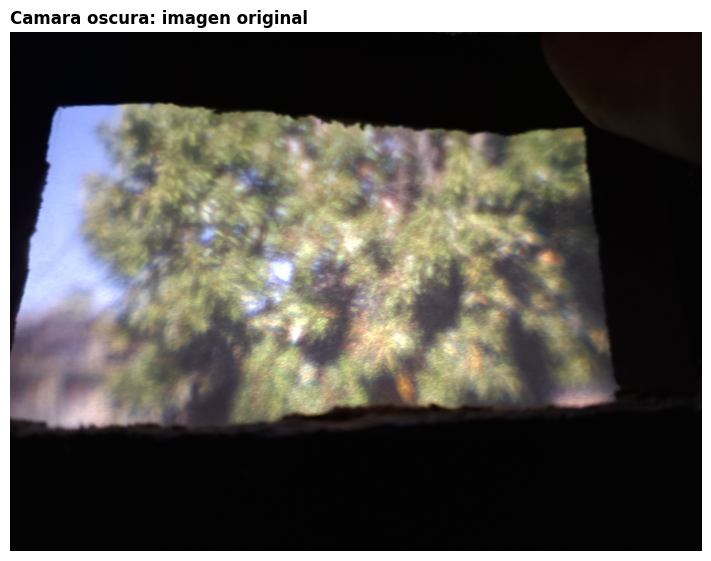

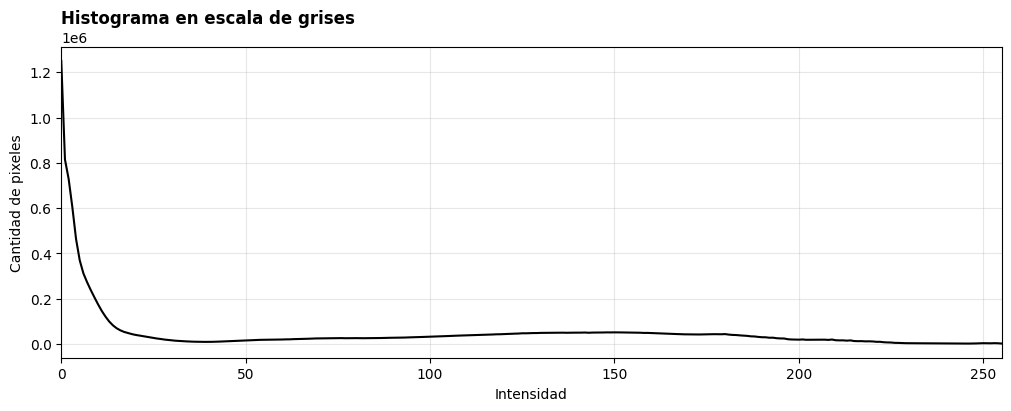

Diagnostico inicial: 
La imagen tiene un fondo negro excesivo (la caja de la camara oscura) que ocupa gran parte del encuadre. 
La proyeccion del arbol se ve borrosa por el desenfoque optico propio de la camara oscura y presenta 
bajo contraste: el verde del arbol y el azul del cielo son visibles pero apagados. 

Primera hipotesis: 
Voy a recortar el fondo negro para quedarme solo con la proyeccion util. 
Luego voy a subir el contraste y el brillo para que el verde del arbol y el azul del cielo 
se lean con mas claridad, sin introducir operaciones innecesarias dado que el ruido es bajo.


In [4]:
# Escribi aca el nombre de tu archivo para el caso de camara oscura.
nombre_imagen_camara_oscura = "arbol3.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_camara_oscura_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_camara_oscura != "":
    ruta_camara_oscura = carpeta_imagenes_tfi / nombre_imagen_camara_oscura
    imagen_camara_oscura_rgb = cargar_rgb(ruta_camara_oscura)

    # Mostramos la imagen original y su histograma para empezar el diagnostico.
    mostrar_imagen(imagen_camara_oscura_rgb, "Camara oscura: imagen original")
    mostrar_histograma_gris(imagen_camara_oscura_rgb)

# Escribi aca tu diagnostico inicial.

diagnostico_camara_oscura = ("\nLa imagen tiene un fondo negro excesivo (la caja de la camara oscura) que ocupa gran parte del encuadre. "
"\nLa proyeccion del arbol se ve borrosa por el desenfoque optico propio de la camara oscura y presenta "
"\nbajo contraste: el verde del arbol y el azul del cielo son visibles pero apagados. ")
# Escribi aca tu primera hipotesis de mejora.

hipotesis_camara_oscura = ("\nVoy a recortar el fondo negro para quedarme solo con la proyeccion util. "
"\nLuego voy a subir el contraste y el brillo para que el verde del arbol y el azul del cielo "
"\nse lean con mas claridad, sin introducir operaciones innecesarias dado que el ruido es bajo.")

print("Diagnostico inicial:", diagnostico_camara_oscura)
print("""""")
print("Primera hipotesis:", hipotesis_camara_oscura)

 Herramienta interactiva: Recorte + Rotación / Volteo

In [5]:
# ─────────────────────────────────────────────────────────────
# Herramienta interactiva: Recorte + Rotación / Volteo
#   • Sliders: recortá cada borde (izq, der, arriba, abajo)
#   • Botones: rotá y/o volteá la imagen
#   • ✅ Aplicar: guarda el resultado como nueva imagen base
# ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Estado de transformación ──────────────────────────────────
_estado = {"rotacion": 0, "flip_h": False, "flip_v": False}

# ── Sliders de recorte (en píxeles) ───────────────────────────
_h, _w = imagen_camara_oscura_rgb.shape[:2]

sl_izq    = widgets.IntSlider(min=0, max=_w//2, step=1, value=0,
    description="◀ Izquierda:", style={"description_width":"110px"},
    layout=widgets.Layout(width="500px"))
sl_der    = widgets.IntSlider(min=0, max=_w//2, step=1, value=0,
    description="Derecha ▶:",  style={"description_width":"110px"},
    layout=widgets.Layout(width="500px"))
sl_arriba = widgets.IntSlider(min=0, max=_h//2, step=1, value=0,
    description="▲ Arriba:",   style={"description_width":"110px"},
    layout=widgets.Layout(width="500px"))
sl_abajo  = widgets.IntSlider(min=0, max=_h//2, step=1, value=0,
    description="Abajo ▼:",    style={"description_width":"110px"},
    layout=widgets.Layout(width="500px"))

# ── Botones de rotación / volteo ──────────────────────────────
GRIS  = "#7f8c8d"
AZUL  = "#2980b9"
VERDE = "#27ae60"

def _boton(label, color=AZUL, ancho="140px"):
    b = widgets.Button(description=label,
        layout=widgets.Layout(width=ancho, height="38px"))
    b.style.button_color = color
    b.style.font_weight  = "bold"
    return b

btn_rot_izq  = _boton("↺  −90°")
btn_rot_der  = _boton("↻  +90°")
btn_rot_180  = _boton("⟳  180°")
btn_flip_h   = _boton("↔  Voltear H")
btn_flip_v   = _boton("↕  Voltear V")
btn_reset    = _boton("✖  Resetear", color=GRIS)
btn_aplicar  = _boton("✅  Usar como base", color=VERDE, ancho="180px")

lbl_estado = widgets.Label(value="Rotación: 0°  |  Flip H: No  |  Flip V: No")

salida_cr = widgets.Output()

# ── Función que calcula y muestra el preview ──────────────────
def _preview(change=None):
    img = imagen_camara_oscura_rgb.copy()
    h, w = img.shape[:2]

    # Recorte
    y1 = sl_arriba.value
    y2 = max(y1 + 1, h - sl_abajo.value)
    x1 = sl_izq.value
    x2 = max(x1 + 1, w - sl_der.value)
    img = img[y1:y2, x1:x2]

    # Rotación
    rot = _estado["rotacion"] % 360
    if rot == 90:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif rot == 180:
        img = cv2.rotate(img, cv2.ROTATE_180)
    elif rot == 270:
        img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

    # Volteo
    if _estado["flip_h"]:
        img = cv2.flip(img, 1)
    if _estado["flip_v"]:
        img = cv2.flip(img, 0)

    # Etiqueta de estado
    fh = "Sí" if _estado["flip_h"] else "No"
    fv = "Sí" if _estado["flip_v"] else "No"
    lbl_estado.value = (f"Rotación: {_estado['rotacion']}°  |  "
                        f"Flip H: {fh}  |  Flip V: {fv}  |  "
                        f"Tamaño resultado: {img.shape[1]}×{img.shape[0]} px")

    with salida_cr:
        clear_output(wait=True)
        plt.close("all")
        fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
        axs[0].imshow(imagen_camara_oscura_rgb)
        axs[0].set_title("Original", fontweight="bold", loc="left")
        axs[0].axis("off")
        axs[1].imshow(img)
        axs[1].set_title("Vista previa", fontweight="bold", loc="left")
        axs[1].axis("off")
        display(fig)
        plt.close(fig)

# ── Manejadores de botones ────────────────────────────────────
def _on_rot_izq(b):
    _estado["rotacion"] = (_estado["rotacion"] - 90) % 360
    _preview()

def _on_rot_der(b):
    _estado["rotacion"] = (_estado["rotacion"] + 90) % 360
    _preview()

def _on_rot_180(b):
    _estado["rotacion"] = (_estado["rotacion"] + 180) % 360
    _preview()

def _on_flip_h(b):
    _estado["flip_h"] = not _estado["flip_h"]
    _preview()

def _on_flip_v(b):
    _estado["flip_v"] = not _estado["flip_v"]
    _preview()

def _on_reset(b):
    _estado["rotacion"] = 0
    _estado["flip_h"]   = False
    _estado["flip_v"]   = False
    sl_izq.value = sl_der.value = sl_arriba.value = sl_abajo.value = 0
    _preview()

def _on_aplicar(b):
    global imagen_camara_oscura_rgb
    img = imagen_camara_oscura_rgb.copy()
    h, w = img.shape[:2]
    y1 = sl_arriba.value
    y2 = max(y1 + 1, h - sl_abajo.value)
    x1 = sl_izq.value
    x2 = max(x1 + 1, w - sl_der.value)
    img = img[y1:y2, x1:x2]
    rot = _estado["rotacion"] % 360
    if rot == 90:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif rot == 180:
        img = cv2.rotate(img, cv2.ROTATE_180)
    elif rot == 270:
        img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    if _estado["flip_h"]:
        img = cv2.flip(img, 1)
    if _estado["flip_v"]:
        img = cv2.flip(img, 0)
    imagen_camara_oscura_rgb = img
    with salida_cr:
        clear_output(wait=True)
        plt.close("all")
        fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
        ax.imshow(img)
        ax.set_title(f"✅ Imagen base actualizada  —  {img.shape[1]}×{img.shape[0]} px",
                     fontweight="bold", loc="left")
        ax.axis("off")
        display(fig)
        plt.close(fig)
    lbl_estado.value = (f"✅ Imagen base actualizada  —  "
                        f"{img.shape[1]}×{img.shape[0]} px")

btn_rot_izq.on_click(_on_rot_izq)
btn_rot_der.on_click(_on_rot_der)
btn_rot_180.on_click(_on_rot_180)
btn_flip_h.on_click(_on_flip_h)
btn_flip_v.on_click(_on_flip_v)
btn_reset.on_click(_on_reset)
btn_aplicar.on_click(_on_aplicar)

for sl in [sl_izq, sl_der, sl_arriba, sl_abajo]:
    sl.observe(_preview, names="value")

# ── Layout ────────────────────────────────────────────────────
fila_rot = widgets.HBox([btn_rot_izq, btn_rot_der, btn_rot_180,
                         btn_flip_h, btn_flip_v, btn_reset, btn_aplicar])
panel_cr = widgets.VBox([
    widgets.HTML("<b>✂ Recorte de bordes</b>"),
    sl_arriba, sl_abajo, sl_izq, sl_der,
    widgets.HTML("<b>🔄 Rotación y volteo</b>"),
    fila_rot,
    lbl_estado,
])
display(panel_cr, salida_cr)
_preview()


Output()

Herramienta interactiva para aplicar ajustes a la imagen:

In [9]:
# ─────────────────────────────────────────────────────────────
# Herramienta interactiva tipo "Paint":
#   Activá/desactivá cada operación con su botón.
#   Se aplican en cadena en el orden:
#   Brillo/Contraste → CLAHE → Gaussiano → Mediana
# ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

VERDE  = "#27ae60"
GRIS   = "#7f8c8d"

def _btn(label):
    b = widgets.ToggleButton(
        value=False,
        description=label,
        button_style="",
        layout=widgets.Layout(width="200px", height="40px"),
    )
    b.style.button_color = GRIS
    b.style.font_weight  = "bold"
    return b

btn_bc     = _btn("Brillo / Contraste")
btn_clahe  = _btn("CLAHE en LAB")
btn_gauss  = _btn("Suavizado Gaussiano")
btn_median = _btn("Suavizado Mediana")

# ── Sliders Brillo/Contraste ──────────────────────────────────
alpha_s = widgets.FloatSlider(min=0.5, max=3.0, step=0.1, value=1.6,
    description="Contraste (α):",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))
beta_s  = widgets.IntSlider(min=-100, max=100, step=5, value=30,
    description="Brillo (β):",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))

# ── Sliders CLAHE ─────────────────────────────────────────────
clip_s = widgets.FloatSlider(min=0.5, max=8.0, step=0.5, value=2.5,
    description="clipLimit:",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))
tile_s = widgets.IntSlider(min=2, max=16, step=2, value=8,
    description="tileGridSize:",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))

# ── Sliders Gaussiano ─────────────────────────────────────────
gauss_s = widgets.IntSlider(min=1, max=21, step=2, value=5,
    description="Kernel (impar):",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))

# ── Sliders Mediana ───────────────────────────────────────────
median_s = widgets.IntSlider(min=3, max=21, step=2, value=5,
    description="Kernel (impar):",
    style={"description_width":"130px"}, layout=widgets.Layout(width="460px"))

# ── Paneles de sliders (ocultos por defecto) ──────────────────
panel_bc     = widgets.VBox([alpha_s, beta_s],  layout=widgets.Layout(display="none"))
panel_clahe  = widgets.VBox([clip_s, tile_s],   layout=widgets.Layout(display="none"))
panel_gauss  = widgets.VBox([gauss_s],          layout=widgets.Layout(display="none"))
panel_median = widgets.VBox([median_s],         layout=widgets.Layout(display="none"))

salida2 = widgets.Output()

def aplicar(change=None):
    with salida2:
        clear_output(wait=True)
        plt.close("all")
        if imagen_camara_oscura_rgb is None:
            print("⚠️ Primero cargá y actualizá la imagen base.")
            return
        img = imagen_camara_oscura_rgb.copy()
        pasos = []

        if btn_bc.value:
            img = cv2.convertScaleAbs(img, alpha=alpha_s.value, beta=beta_s.value)
            pasos.append(f"B/C α={alpha_s.value:.1f} β={beta_s.value}")

        if btn_clahe.value:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            l, a, b_ch = cv2.split(lab)
            cl = cv2.createCLAHE(clipLimit=clip_s.value,
                                  tileGridSize=(tile_s.value, tile_s.value))
            img = cv2.cvtColor(cv2.merge([cl.apply(l), a, b_ch]), cv2.COLOR_LAB2RGB)
            pasos.append(f"CLAHE clip={clip_s.value:.1f} tile={tile_s.value}")

        if btn_gauss.value:
            k = gauss_s.value
            img = cv2.GaussianBlur(img, (k, k), 0)
            pasos.append(f"Gauss {k}×{k}")

        if btn_median.value:
            img = cv2.medianBlur(img, median_s.value)
            pasos.append(f"Median {median_s.value}×{median_s.value}")

        titulo = " → ".join(pasos) if pasos else "(sin operaciones activas)"

        # ── Comparación Original | Editada ────────────────────
        fig1, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
        ejes[0].imshow(imagen_camara_oscura_rgb)
        ejes[0].set_title("Original", fontweight="bold", loc="left")
        ejes[0].axis("off")
        ejes[1].imshow(img)
        ejes[1].set_title(titulo, fontweight="bold", loc="left")
        ejes[1].axis("off")
        display(fig1)
        plt.close(fig1)

        # ── Histograma en grises ──────────────────────────────
        img_gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        histograma, bordes = np.histogram(img_gris.flatten(), bins=256, range=[0, 256])
        fig2, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
        ax.plot(bordes[:-1], histograma, color="black")
        ax.set_title("Histograma en escala de grises", fontweight="bold", loc="left")
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Cantidad de píxeles")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
        display(fig2)
        plt.close(fig2)

def toggle_color(btn, panel):
    def _handler(change):
        if change["new"]:
            btn.style.button_color = VERDE
            panel.layout.display = "flex"
        else:
            btn.style.button_color = GRIS
            panel.layout.display = "none"
        aplicar()
    return _handler

btn_bc.observe(toggle_color(btn_bc, panel_bc),          names="value")
btn_clahe.observe(toggle_color(btn_clahe, panel_clahe),  names="value")
btn_gauss.observe(toggle_color(btn_gauss, panel_gauss),  names="value")
btn_median.observe(toggle_color(btn_median, panel_median), names="value")

for sl in [alpha_s, beta_s, clip_s, tile_s, gauss_s, median_s]:
    sl.observe(aplicar, names="value")

barra = widgets.HBox([btn_bc, btn_clahe, btn_gauss, btn_median])
panel_completo = widgets.VBox([barra, panel_bc, panel_clahe, panel_gauss, panel_median])
display(panel_completo, salida2)
aplicar()


Output()

### Estrategia 1 para camara oscura

Completa este bloque con una primera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.


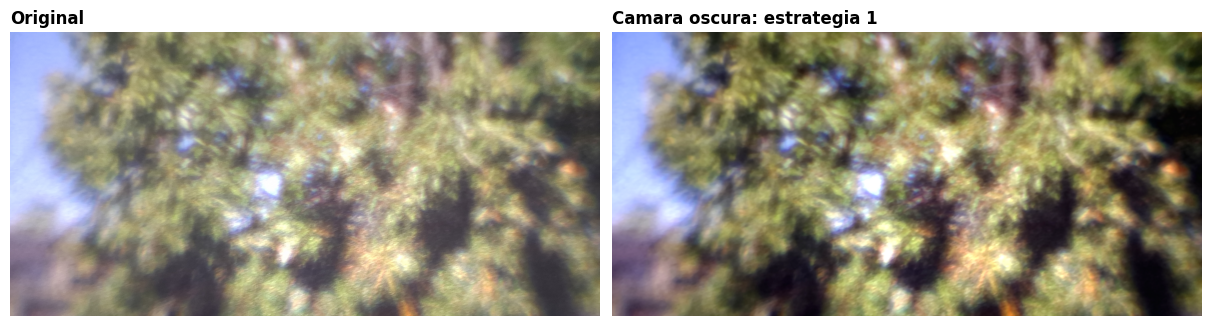

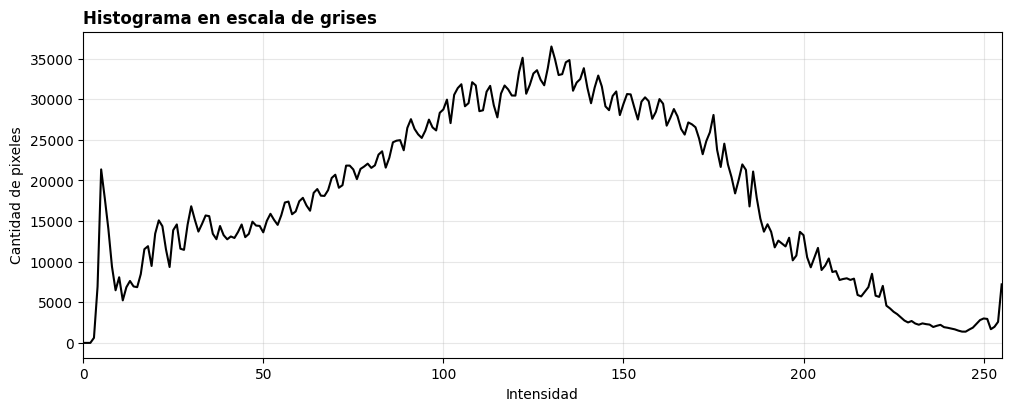

Problema que resolvio: bajo contraste global; el verde del árbol y el azul del cielo estaban apagados. 
Cambio que produjo: el histograma se extiende hacia los valores altos; el follaje verde y el cielo azul ganan presencia tonal y se diferencian mejor del fondo oscuro. 
Justificacion de parametros: alpha=1.30 estira el contraste de forma proporcional; beta=-65 oscurece levemente el brillo evitando saturar las zonas claras; medianBlur(9) suaviza el grano amplificado preservando bordes mejor que Gaussiano. 
Limite que mantiene: la transformación es uniforme y no adapta la mejora a zonas con diferente iluminación; el desenfoque óptico propio de la cámara oscura no se puede corregir digitalmente.


In [16]:
# Estrategia 1: convertScaleAbs (brillo + contraste global) + medianBlur
#
# Diagnóstico: la imagen presenta bajo contraste; el verde del árbol y el azul
# del cielo son visibles pero apagados. El histograma está comprimido en la
# parte media-baja del rango. No hay ruido marcado.
# → Una transformación lineal global puede estirar el rango tonal de forma directa
#   y un suavizado de mediana suaviza el grano sin borrar bordes.

imagen_camara_estrategia_1 = None
if imagen_camara_oscura_rgb is not None:
    # Paso 1: ajuste lineal de brillo y contraste
    # alpha=1.30 estira el rango tonal; beta=-65 oscurece levemente el histograma
    imagen_camara_estrategia_1 = cv2.convertScaleAbs(imagen_camara_oscura_rgb, alpha=1.30, beta=-65)

    # Paso 2: medianBlur(9) suaviza el grano amplificado preservando bordes
    imagen_camara_estrategia_1 = cv2.medianBlur(imagen_camara_estrategia_1, 9)

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_1,
        "Original",
        "Camara oscura: estrategia 1"
    )
    mostrar_histograma_gris(imagen_camara_estrategia_1)

observacion_camara_estrategia_1 = (
    "Problema que resolvio: bajo contraste global; el verde del árbol y el azul del cielo estaban apagados. "
    "\nCambio que produjo: el histograma se extiende hacia los valores altos; el follaje verde y el cielo azul "
    "ganan presencia tonal y se diferencian mejor del fondo oscuro. "
    "\nJustificacion de parametros: alpha=1.30 estira el contraste de forma proporcional; beta=-65 oscurece levemente "
    "el brillo evitando saturar las zonas claras; medianBlur(9) suaviza el grano amplificado preservando bordes mejor que Gaussiano. "
    "\nLimite que mantiene: la transformación es uniforme y no adapta la mejora a zonas con diferente iluminación; "
    "el desenfoque óptico propio de la cámara oscura no se puede corregir digitalmente."
)
print(observacion_camara_estrategia_1)


### Estrategia 2 para camara oscura

Completa este bloque con una primera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.


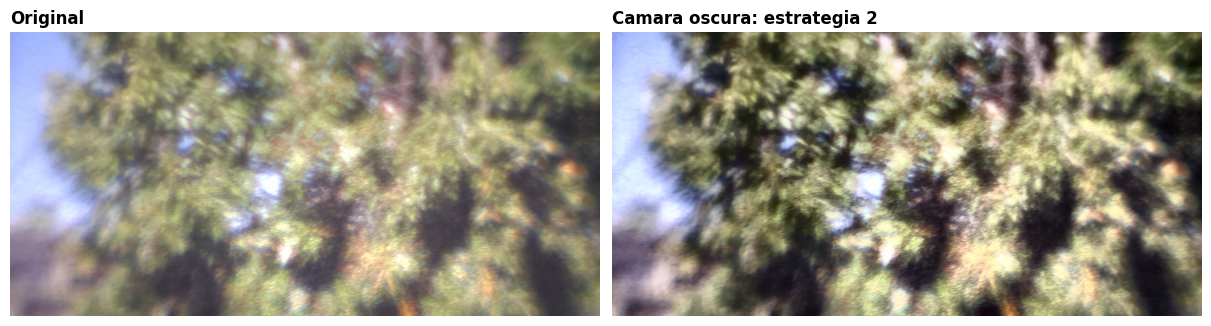

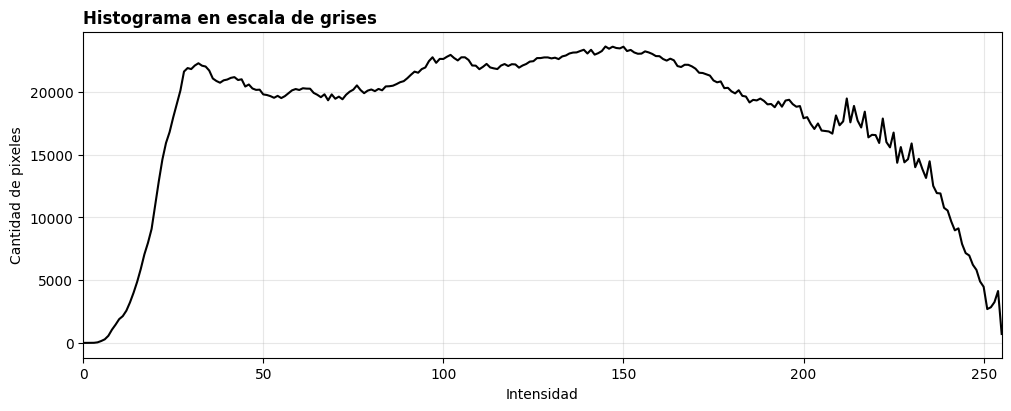

Problema que resolvio: contraste bajo y no uniforme entre las zonas de follaje (más oscuras) y el cielo (más claro); detalles del árbol sin separación tonal suficiente. 
Cambio que produjo: el contraste se mejora de forma localizada por zonas; el follaje gana detalle sin quemar las áreas ya iluminadas del cielo. Los canales de color no se modifican. 
Justificacion de parametros: clipLimit=2.0 limita la amplificación para no exagerar el contraste; tileGridSize=(4,4) usa zonas más grandes que adaptan la mejora con menos granularidad; GaussianBlur con kernel=3 aplica un suavizado leve que reduce el grano amplificado sin borrar contornos. 
Limite que mantiene: el brillo global sube menos que con convertScaleAbs; el desenfoque óptico persiste.


In [17]:
# Estrategia 2: CLAHE en canal L (espacio LAB) + GaussianBlur
#
# Diagnóstico: la degradación de contraste no es uniforme en toda la imagen;
# el follaje tiene zonas más oscuras y el cielo tiene zonas más claras.
# Una mejora local y adaptativa por zonas puede recuperar detalle sin
# quemar las zonas ya más iluminadas del cielo.
# → Operar solo sobre la luminancia (canal L) en LAB preserva los colores intactos.

imagen_camara_estrategia_2 = None
if imagen_camara_oscura_rgb is not None:
    # Paso 1: convertir a LAB para separar luminancia del color
    imagen_lab = cv2.cvtColor(imagen_camara_oscura_rgb, cv2.COLOR_RGB2LAB)
    canal_l, canal_a, canal_b = cv2.split(imagen_lab)

    # Paso 2: CLAHE adaptativo por zonas solo sobre el canal L
    # clipLimit=2.0 limita la amplificación; tileGridSize=(4,4) usa zonas más grandes
    clahe_camara = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    canal_l_mejorado = clahe_camara.apply(canal_l)

    # Paso 3: reconstruir la imagen sin tocar los canales de color
    imagen_lab_mejorada = cv2.merge([canal_l_mejorado, canal_a, canal_b])
    imagen_camara_estrategia_2 = cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)

    # Paso 4: GaussianBlur con kernel=3 suaviza levemente sin perder bordes
    imagen_camara_estrategia_2 = cv2.GaussianBlur(imagen_camara_estrategia_2, (3, 3), 0)

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_2,
        "Original",
        "Camara oscura: estrategia 2"
    )
    mostrar_histograma_gris(imagen_camara_estrategia_2)

observacion_camara_estrategia_2 = (
    "Problema que resolvio: contraste bajo y no uniforme entre las zonas de follaje (más oscuras) "
    "y el cielo (más claro); detalles del árbol sin separación tonal suficiente. "
    "\nCambio que produjo: el contraste se mejora de forma localizada por zonas; el follaje gana "
    "detalle sin quemar las áreas ya iluminadas del cielo. Los canales de color no se modifican. "
    "\nJustificacion de parametros: clipLimit=2.0 limita la amplificación para no exagerar el "
    "contraste; tileGridSize=(4,4) usa zonas más grandes que adaptan la mejora con menos granularidad; "
    "GaussianBlur con kernel=3 aplica un suavizado leve que reduce el grano amplificado sin borrar contornos. "
    "\nLimite que mantiene: el brillo global sube menos que con convertScaleAbs; "
    "el desenfoque óptico persiste."
)
print(observacion_camara_estrategia_2)


# Eleccion de la version final 


Se elige la Estrategia 1 (convertScaleAbs + medianBlur) como versión final. 
La imagen de cámara oscura presenta una degradación uniforme en todo el encuadre: 
bajo contraste global sin zonas con iluminación diferencial marcada. 
En ese contexto, una transformación lineal con alpha=1.30 y beta=-65 estira el rango tonal 
de forma directa y proporcional, levantando el follaje y el cielo sin saturar las zonas más claras. 
El medianBlur(9) suaviza el grano amplificado preservando los bordes mejor que un Gaussiano equivalente. 
La Estrategia 2 (CLAHE en LAB + GaussianBlur) mejora el contraste de forma localizada, 
lo cual es una ventaja cuando la degradación varía por zonas; 
pero en una imagen tan uniformente subexpuesta la mejora perceptible es menor 
y el suavizado final con kernel=3 resulta insuficiente para el grano residual. 
Por eso la Estrategia 1 produce un resultado más legible y proporcional al problema detectado.


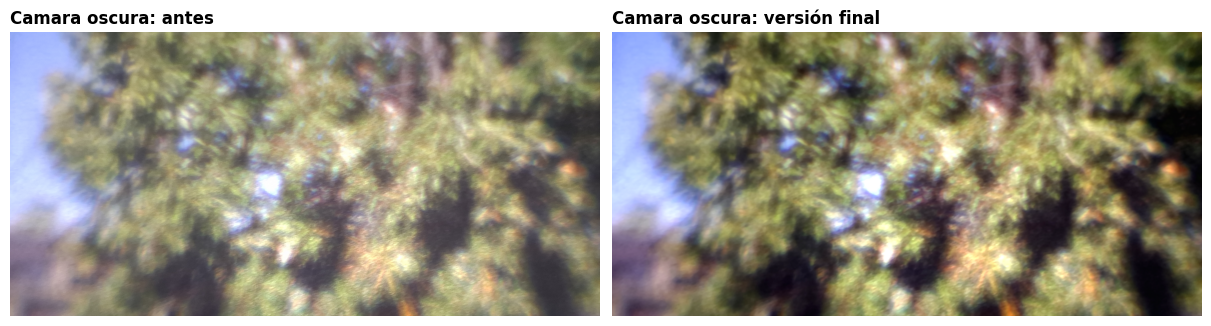

Salida guardada en: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1_Corregido\carpeta_salidas_tfi1\camara_oscura_final.png


In [19]:
# Elegimos la Estrategia 1 (convertScaleAbs + medianBlur) como versión final.
imagen_camara_final = imagen_camara_estrategia_1

justificacion_camara_final = (
    "\nSe elige la Estrategia 1 (convertScaleAbs + medianBlur) como versión final. "
    "\nLa imagen de cámara oscura presenta una degradación uniforme en todo el encuadre: "
    "\nbajo contraste global sin zonas con iluminación diferencial marcada. "
    "\nEn ese contexto, una transformación lineal con alpha=1.30 y beta=-65 estira el rango tonal "
    "\nde forma directa y proporcional, levantando el follaje y el cielo sin saturar las zonas más claras. "
    "\nEl medianBlur(9) suaviza el grano amplificado preservando los bordes mejor que un Gaussiano equivalente. "
    "\nLa Estrategia 2 (CLAHE en LAB + GaussianBlur) mejora el contraste de forma localizada, "
    "\nlo cual es una ventaja cuando la degradación varía por zonas; "
    "\npero en una imagen tan uniformente subexpuesta la mejora perceptible es menor "
    "\ny el suavizado final con kernel=3 resulta insuficiente para el grano residual. "
    "\nPor eso la Estrategia 1 produce un resultado más legible y proporcional al problema detectado."
)
print(justificacion_camara_final)

if imagen_camara_final is not None:
    ruta_salida_camara = carpeta_salidas_tfi / "camara_oscura_final.png"
    guardar_rgb(ruta_salida_camara, imagen_camara_final)

    if imagen_camara_oscura_rgb is not None:
        mostrar_comparacion(
            imagen_camara_oscura_rgb,
            imagen_camara_final,
            "Camara oscura: antes",
            "Camara oscura: versión final"
        )

    print(f"Salida guardada en: {ruta_salida_camara.resolve()}")


CONCLUSION: 
"En este caso detectamos que el problema principal era una degradación uniforme en todo el encuadre: bajo contraste global, imagen oscura y desenfoque óptico propio de la cámara oscura. El histograma estaba comprimido en la parte media-baja del rango y tanto el verde del árbol como el azul del cielo aparecían apagados, sin separación tonal clara.
Probamos dos estrategias comparables.
La primera aplicó una transformación lineal con convertScaleAbs (alpha=1.30, beta=-65) seguida de medianBlur(9) para suavizar el grano amplificado preservando los bordes. Produjo el cambio más directo y perceptible: el histograma se extiende hacia los valores altos y el follaje y el cielo ganan presencia tonal de forma pareja en toda la imagen.
La segunda estrategia aplicó CLAHE sobre el canal L en espacio LAB (clipLimit=2.0, tileGridSize=(4,4)) seguido de GaussianBlur(3,3). Su fortaleza es adaptar el contraste por zonas locales, lo cual sería ideal si la degradación fuera no uniforme; pero en esta imagen, donde el subcontraste es homogéneo en todo el encuadre, la mejora es menos perceptible y el suavizado final con kernel=3 resulta insuficiente para el grano residual.
Por eso elegimos la Estrategia 1. Resolvió mejor el problema de contraste uniforme, mejoró la legibilidad general de forma proporcional al tipo de degradación y mantuvo como límite que la transformación es global y no puede corregir el desenfoque óptico propio de la cámara oscura."


## Caso 2. Imagen de medio grafico color

En este caso el problema puede estar en la geometria, en el contraste, en el color o en danos localizados. Antes de intervenir, conviene distinguir si el principal obstaculo es la perspectiva, la cromaticidad, la iluminacion o la presencia de manchas.

**Sugerencias tecnicas posibles:** rectificacion de perspectiva, mejora sobre HSV o LAB, `CLAHE`, suavizado e `inpainting` si hubiera dano localizado.


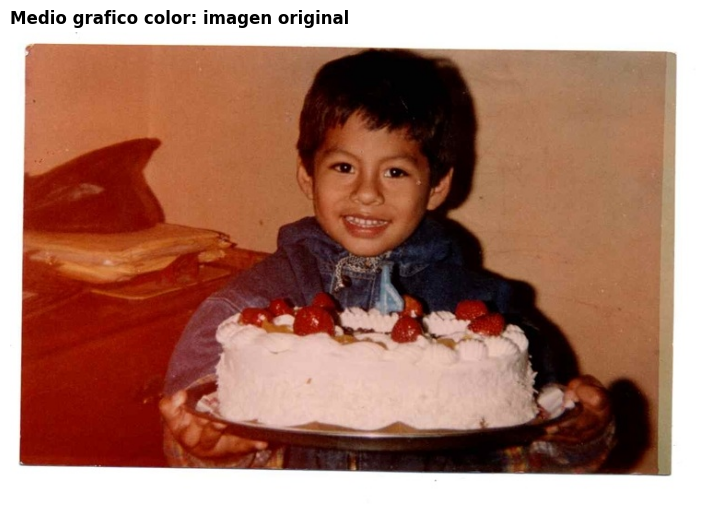

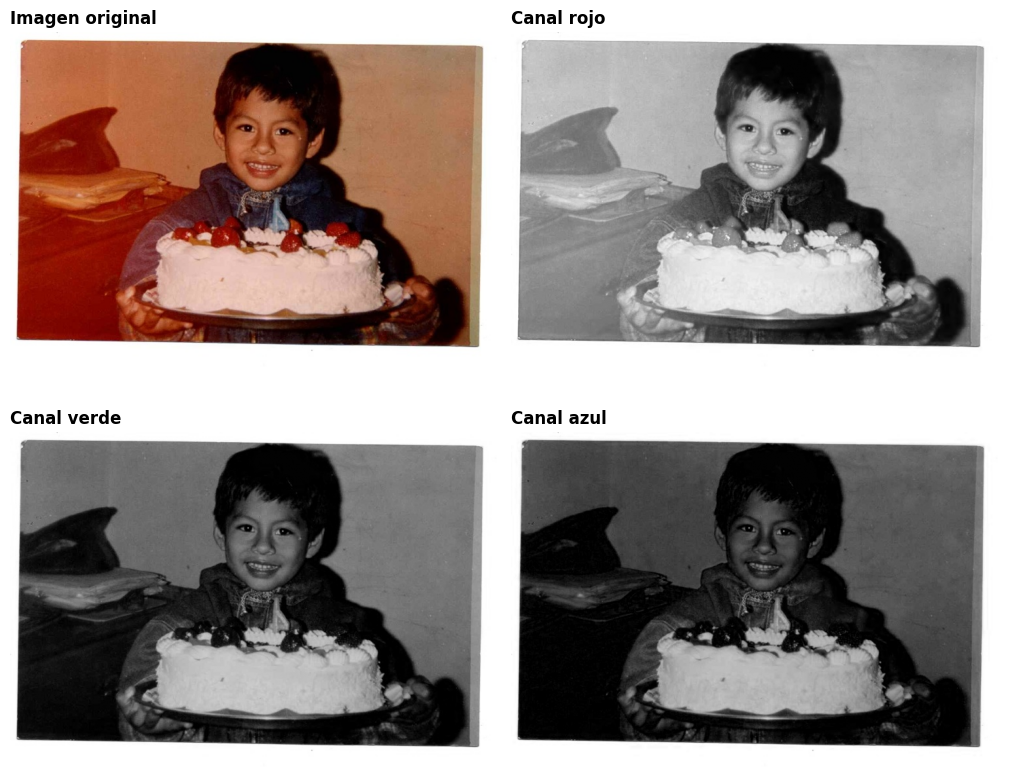

Diagnostico inicial: La imagen presenta una dominante rojiza/anaranjada marcada y contraste moderado-bajo. Esto hace que los colores se vean corridos y reduce detalle útil en piel, ropa y fondo.
Objetivo de mejora: Corregir primero la dominante cromática y luego mejorar contraste de forma controlada, manteniendo apariencia natural.


In [21]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico color.
nombre_imagen_medio_color = "imagen2A.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_color_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_color != "":
    ruta_medio_color = carpeta_imagenes_tfi / nombre_imagen_medio_color
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Mostramos la imagen original y sus canales para orientar el diagnostico.
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_color = "La imagen presenta una dominante rojiza/anaranjada marcada y contraste moderado-bajo. Esto hace que los colores se vean corridos y reduce detalle útil en piel, ropa y fondo."

# Escribi aca que queres priorizar en la mejora.
objetivo_medio_color = "Corregir primero la dominante cromática y luego mejorar contraste de forma controlada, manteniendo apariencia natural."

print("Diagnostico inicial:", diagnostico_medio_color)
print("Objetivo de mejora:", objetivo_medio_color)


### Estrategia 1 




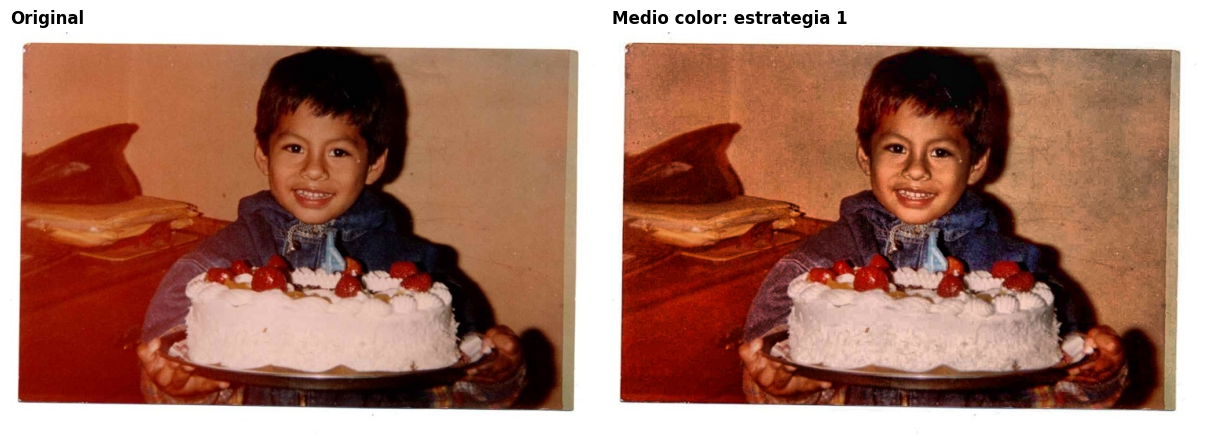

Problema que resolvio: contraste local apagado con una dominante calida que ocultaba detalles. 
Cambio que produjo: mejor separacion entre tonos claros y oscuros, con mas detalle visible en rostro, ropa y torta. 
Justificacion de parametros: CLAHE en V con clipLimit=2.5 y tileGridSize=(8,8) mejoro detalle de luminancia sin tocar el color de forma directa. 
Limite que mantiene: la dominante rojiza disminuye poco, porque la estrategia actua sobre luminancia y no corrige el balance entre canales.


In [26]:
# Partimos de una copia de la imagen original si ya la cargaste.
imagen_medio_color_estrategia_1 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # 1) Convertimos a HSV para separar color de luminancia.
    imagen_hsv = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2HSV)
    canal_h, canal_s, canal_v = cv2.split(imagen_hsv)

    # 2) Mejoramos el contraste local solo sobre la luminancia.
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    canal_v_mejorado = clahe.apply(canal_v)

    # 3) Reconstruimos la imagen color con la nueva luminancia.
    imagen_hsv_mejorada = cv2.merge([canal_h, canal_s, canal_v_mejorado])
    imagen_medio_color_estrategia_1 = cv2.cvtColor(imagen_hsv_mejorada, cv2.COLOR_HSV2RGB)

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )

observacion_medio_color_estrategia_1 = (
    "Problema que resolvio: contraste local apagado con una dominante calida que ocultaba detalles. "
    "\nCambio que produjo: mejor separacion entre tonos claros y oscuros, con mas detalle visible en rostro, ropa y torta. "
    "\nJustificacion de parametros: CLAHE en V con clipLimit=2.5 y tileGridSize=(8,8) mejoro detalle de luminancia sin tocar el color de forma directa. "
    "\nLimite que mantiene: la dominante rojiza disminuye poco, porque la estrategia actua sobre luminancia y no corrige el balance entre canales."
)
print(observacion_medio_color_estrategia_1)


### Estrategia 2 




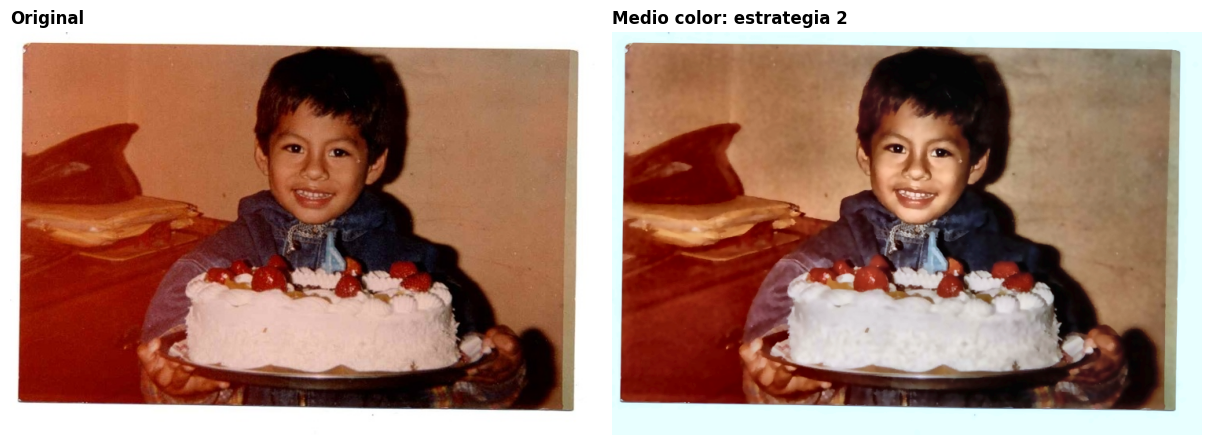

Problema que resolvio: dominante rojiza/anaranjada junto con contraste apagado. 
Cambio que produjo: colores mas equilibrados y una mejor lectura de rostro, ropa, torta y fondo sin depender solo del brillo. 
Justificacion de parametros: las ganancias por canal se limitaron con np.clip para corregir la dominante sin desplazar demasiado tonos naturales; bilateral d=7, sigmaColor=35 y sigmaSpace=35 controlo grano, y CLAHE en L con clipLimit=1.6 reforzo contraste sin castigar el color. 
Limite que mantiene: la correccion es aproximada y no recupera colores originales exactos, porque la foto ya llega degradada desde captura o material impreso.


In [27]:
# Construimos una segunda estrategia para poder discutir una eleccion.
imagen_medio_color_estrategia_2 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy().astype(np.float32)

    # 1) Balance simple y moderado por promedio de canales para reducir la dominante rojiza.
    promedio_r = np.mean(imagen_medio_color_estrategia_2[:, :, 0])
    promedio_g = np.mean(imagen_medio_color_estrategia_2[:, :, 1])
    promedio_b = np.mean(imagen_medio_color_estrategia_2[:, :, 2])
    promedio_general = (promedio_r + promedio_g + promedio_b) / 3.0

    ganancia_r = 1.0 + 0.45 * ((promedio_general / promedio_r) - 1.0)
    ganancia_g = 1.0 + 0.45 * ((promedio_general / promedio_g) - 1.0)
    ganancia_b = 1.0 + 0.45 * ((promedio_general / promedio_b) - 1.0)

    ganancia_r = np.clip(ganancia_r, 0.9, 1.08)
    ganancia_g = np.clip(ganancia_g, 0.95, 1.08)
    ganancia_b = np.clip(ganancia_b, 0.95, 1.12)

    imagen_medio_color_estrategia_2[:, :, 0] *= ganancia_r
    imagen_medio_color_estrategia_2[:, :, 1] *= ganancia_g
    imagen_medio_color_estrategia_2[:, :, 2] *= ganancia_b
    imagen_medio_color_estrategia_2 = np.clip(imagen_medio_color_estrategia_2, 0, 255).astype(np.uint8)

    # 2) Suavizado bilateral leve para no exagerar el grano del escaneo.
    imagen_medio_color_estrategia_2 = cv2.bilateralFilter(
        imagen_medio_color_estrategia_2, d=7, sigmaColor=35, sigmaSpace=35
    )

    # 3) Mejora suave de contraste en luminancia usando LAB.
    imagen_lab = cv2.cvtColor(imagen_medio_color_estrategia_2, cv2.COLOR_RGB2LAB)
    canal_l, canal_a, canal_b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=1.6, tileGridSize=(8, 8))
    canal_l_mejorado = clahe.apply(canal_l)
    imagen_lab_mejorada = cv2.merge([canal_l_mejorado, canal_a, canal_b])
    imagen_medio_color_estrategia_2 = cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )

observacion_medio_color_estrategia_2 = (
    "Problema que resolvio: dominante rojiza/anaranjada junto con contraste apagado. "
    "\nCambio que produjo: colores mas equilibrados y una mejor lectura de rostro, ropa, torta y fondo sin depender solo del brillo. "
    "\nJustificacion de parametros: las ganancias por canal se limitaron con np.clip para corregir la dominante sin desplazar demasiado tonos naturales; "
    "bilateral d=7, sigmaColor=35 y sigmaSpace=35 controlo grano, y CLAHE en L con clipLimit=1.6 reforzo contraste sin castigar el color. "
    "\nLimite que mantiene: la correccion es aproximada y no recupera colores originales exactos, porque la foto ya llega degradada desde captura o material impreso."
)
print(observacion_medio_color_estrategia_2)


# Eleccion de la version final 

Se elige la estrategia 2 porque responde mejor al problema principal observado: la dominante rojiza/anaranjada. 
Primero corrige el desequilibrio cromatico entre canales, despues suaviza levemente el grano y finalmente mejora el contraste en luminancia. 
Frente a la estrategia 1, produce una imagen mas natural y legible, especialmente en piel, ropa y fondo. 
Su limite es que la correccion de color sigue siendo aproximada y no reconstruye con exactitud los tonos originales de la fotografia impresa.


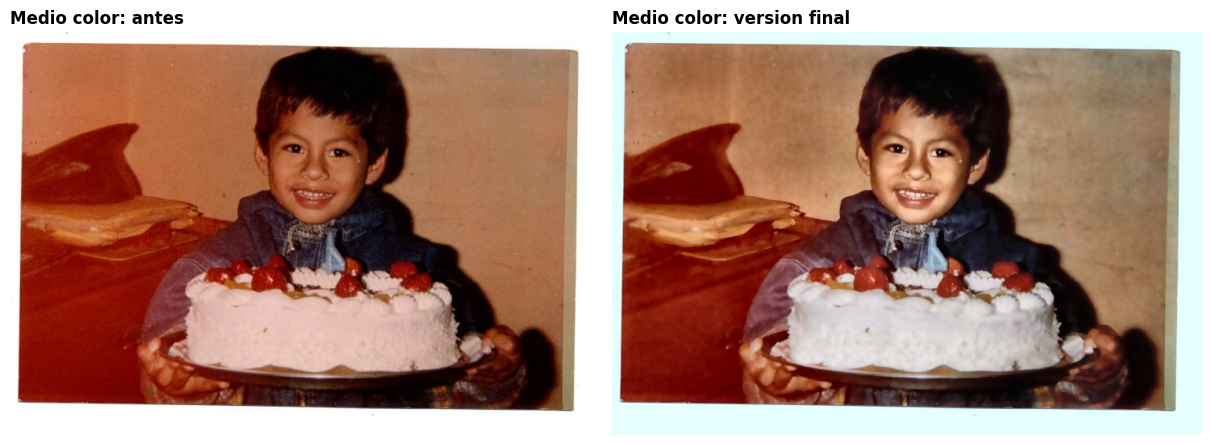

Salida guardada en: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1_Corregido\carpeta_salidas_tfi1\medio_grafico_color_final.png


In [28]:
# Elegi la version final para este caso.
imagen_medio_color_final = imagen_medio_color_estrategia_2

# Justifica por que conservas esta version.
justificacion_medio_color_final = (
    "Se elige la estrategia 2 porque responde mejor al problema principal observado: la dominante rojiza/anaranjada. "
    "\nPrimero corrige el desequilibrio cromatico entre canales, despues suaviza levemente el grano y finalmente mejora el contraste en luminancia. "
    "\nFrente a la estrategia 1, produce una imagen mas natural y legible, especialmente en piel, ropa y fondo. "
    "\nSu limite es que la correccion de color sigue siendo aproximada y no reconstruye con exactitud los tonos originales de la fotografia impresa."
)
print(justificacion_medio_color_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")

CONCLUSION: 
"En este caso detectamos que el problema principal no era la perspectiva ni daños localizados, sino una dominante rojiza/anaranjada junto con contraste apagado. Eso hacía que los colores se vieran corridos y que se perdieran detalles en la piel, la ropa, la torta y el fondo.Probamos dos estrategias comparables. 
La primera trabajó sobre la luminancia en HSV con CLAHE para recuperar contraste local sin modificar directamente el color. Mejoró bastante el detalle, pero mantuvo gran parte de la dominante cálida.La segunda estrategia atacó primero el problema principal: hizo una corrección moderada del balance entre canales para bajar la dominante rojiza, después aplicó un suavizado bilateral leve para no exagerar el grano, y al final mejoró el contraste en luminancia con CLAHE sobre LAB. Esta estrategia dio un resultado más natural y más equilibrado.Por eso elegimos la estrategia 2. 
Resolvió mejor el problema cromático, mejoró la legibilidad general y mantuvo como límite que la corrección de color sigue siendo aproximada, porque la imagen original ya llega degradada desde la captura o desde el material impreso."


## Caso 3. Imagen de medio grafico blanco/negro

En este caso suele importar la legibilidad. El objetivo es separar de manera razonable el fondo y los trazos, sin borrar informacion importante. Por eso conviene pensar si necesitas trabajar en grises, suavizar, umbralizar y limpiar la mascara resultante.

**Sugerencias tecnicas posibles:** conversion a grises, suavizado, umbral global, `Otsu`, `adaptiveThreshold`, apertura o clausura morfologica.


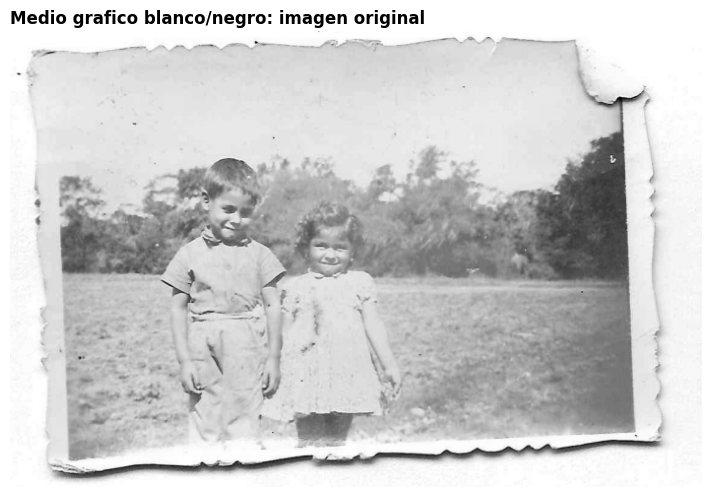

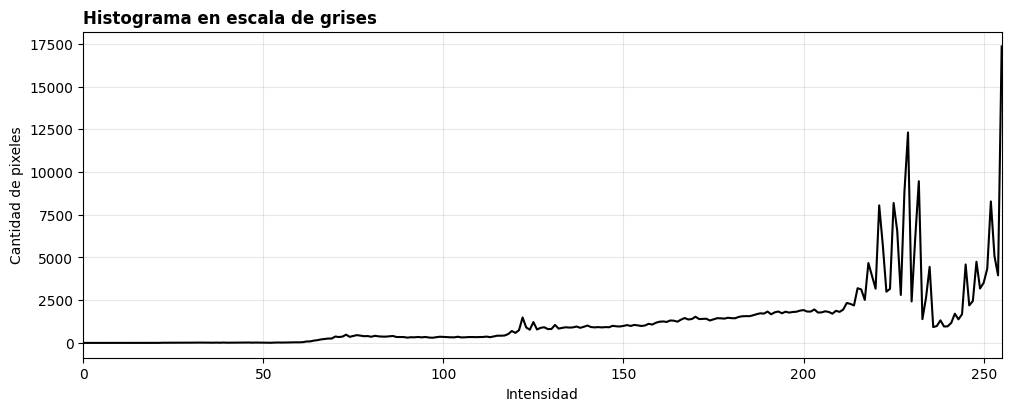

Diagnostico inicial: Imagen muy clara y sin contraste. Histograma concentrado en tonos altos (150-255).
 Los rostros y el fondo se ven lavados sin separación clara.
Objetivo de mejora: Mejorar el contraste local con CLAHE para recuperar detalles en los rostros y el fondo
 sin amplificar el grano ni quemar las zonas ya claras.


In [29]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico blanco/negro.
nombre_imagen_medio_bn = "imagenBN1.PNG"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_bn_gris = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_bn != "":
    ruta_medio_bn = carpeta_imagenes_tfi / nombre_imagen_medio_bn
    imagen_medio_bn_gris = cargar_gris(ruta_medio_bn)

    # Mostramos la imagen original y su histograma para evaluar contraste y separacion tonal.
    mostrar_imagen(imagen_medio_bn_gris, "Medio grafico blanco/negro: imagen original")
    mostrar_histograma_gris(imagen_medio_bn_gris)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_bn = (
    "Imagen muy clara y sin contraste. Histograma concentrado en tonos altos (150-255).\n "
    "Los rostros y el fondo se ven lavados sin separación clara."
)

# Escribi aca que esperas recuperar o mejorar.
objetivo_medio_bn = (
    "Mejorar el contraste local con CLAHE para recuperar detalles en los rostros y el fondo\n "
    "sin amplificar el grano ni quemar las zonas ya claras."
)

print("Diagnostico inicial:", diagnostico_medio_bn)
print("Objetivo de mejora:", objetivo_medio_bn)


### Estrategia 1 




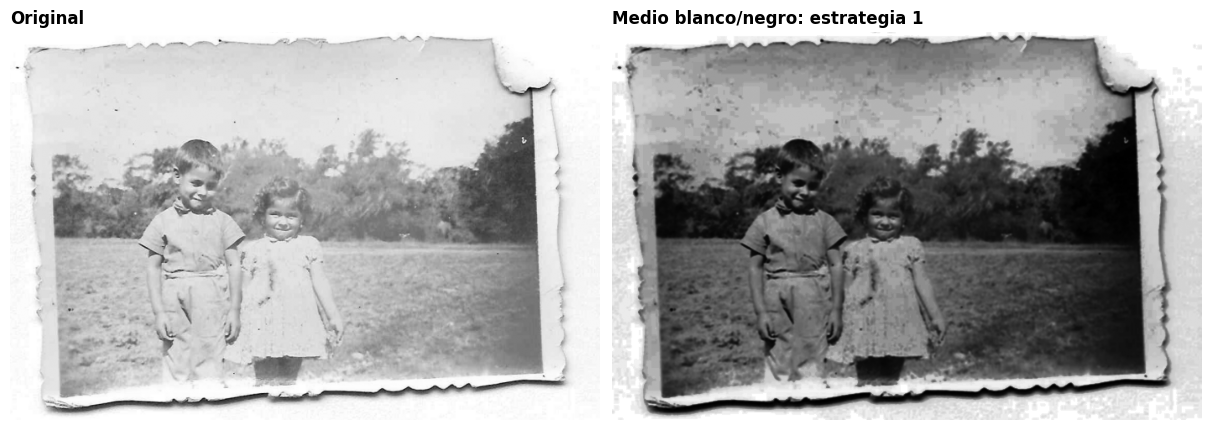

Problema que resolvio: contraste apagado e histograma concentrado en tonos altos (150-255). 
Cambio que produjo: contraste notablemente mayor entre figuras y fondo, con mejor separación entre rostros y escena. 
Justificacion de parametros: GaussianBlur(3,3) suaviza el grano leve sin perder bordes; equalizeHist redistribuye todos los tonos en el rango 0-255 para máxima separación tonal. 
Limite que mantiene: puede exagerar el contraste en zonas ya muy claras (cielo, bordes del papel), produciendo una apariencia artificial.


In [30]:
# Estrategia 1: Suavizado leve + Ecualización global de histograma
imagen_medio_bn_estrategia_1 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_1 = imagen_medio_bn_gris.copy()

    # Paso 1: GaussianBlur(3,3) — suaviza el grano leve sin perder bordes
    suavizada_1 = cv2.GaussianBlur(imagen_medio_bn_estrategia_1, (3, 3), 0)

    # Paso 2: equalizeHist — redistribuye tonos en todo el rango 0-255
    imagen_medio_bn_estrategia_1 = cv2.equalizeHist(suavizada_1)

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_1,
        "Original",
        "Medio blanco/negro: estrategia 1"
    )

observacion_medio_bn_estrategia_1 = (
    "Problema que resolvio: contraste apagado e histograma concentrado en tonos altos (150-255). "
    "\nCambio que produjo: contraste notablemente mayor entre figuras y fondo, con mejor separación entre rostros y escena. "
    "\nJustificacion de parametros: GaussianBlur(3,3) suaviza el grano leve sin perder bordes; equalizeHist redistribuye todos los tonos en el rango 0-255 para máxima separación tonal. "
    "\nLimite que mantiene: puede exagerar el contraste en zonas ya muy claras (cielo, bordes del papel), produciendo una apariencia artificial."
)
print(observacion_medio_bn_estrategia_1)


### Estrategia 2 




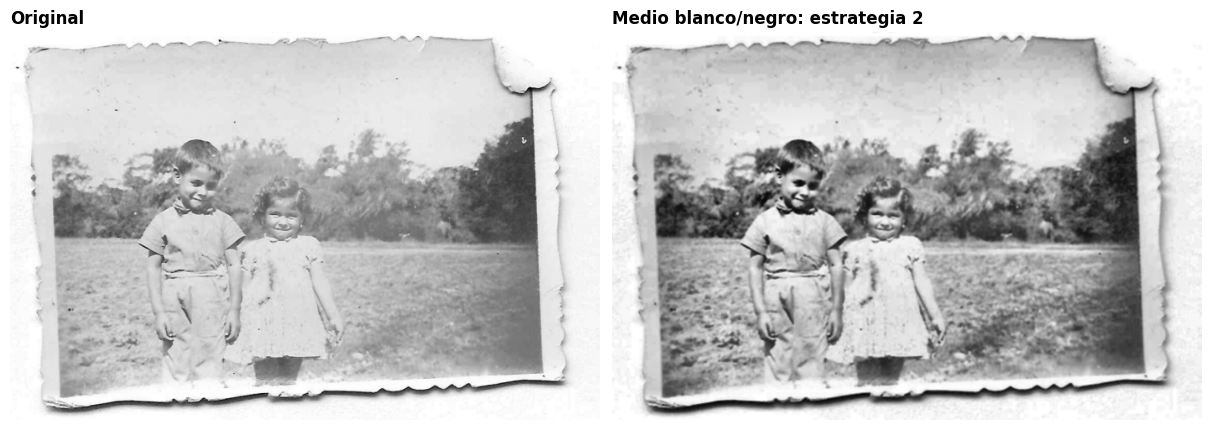

Problema que resolvio: contraste apagado e histograma concentrado en tonos altos (150-255), perdida de detalles. 
Cambio que produjo: mejora de contraste localizada en rostros y pasto sin quemar las áreas ya claras del papel. 
Justificacion de parametros: GaussianBlur(3,3) suaviza el grano; CLAHE(clipLimit=2.0, tileGridSize=(8,8)) mejora contraste por zonas locales adaptando a la distribución tonal de cada región. 
Limite que mantiene: mejora más suave y natural que equalizeHist, pero sin el dramatismo del histograma global; la imagen conserva más fidelidad a la fotografía original.


In [31]:
# Estrategia 2: Suavizado leve + CLAHE (ecualización adaptiva local)
imagen_medio_bn_estrategia_2 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_2 = imagen_medio_bn_gris.copy()

    # Paso 1: GaussianBlur(3,3) — mismo suavizado previo
    suavizada_2 = cv2.GaussianBlur(imagen_medio_bn_estrategia_2, (3, 3), 0)

    # Paso 2: CLAHE — ecualiza por zonas locales, sin saturar las áreas claras
    clahe_bn = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    imagen_medio_bn_estrategia_2 = clahe_bn.apply(suavizada_2)

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_2,
        "Original",
        "Medio blanco/negro: estrategia 2"
    )

observacion_medio_bn_estrategia_2 = (
    "Problema que resolvio: contraste apagado e histograma concentrado en tonos altos (150-255), perdida de detalles. "
    "\nCambio que produjo: mejora de contraste localizada en rostros y pasto sin quemar las áreas ya claras del papel. "
    "\nJustificacion de parametros: GaussianBlur(3,3) suaviza el grano; CLAHE(clipLimit=2.0, tileGridSize=(8,8)) mejora contraste por zonas locales adaptando a la distribución tonal de cada región. "
    "\nLimite que mantiene: mejora más suave y natural que equalizeHist, pero sin el dramatismo del histograma global; la imagen conserva más fidelidad a la fotografía original."
)
print(observacion_medio_bn_estrategia_2)


# Eleccion de la version final 

Se elige la Estrategia 2 (CLAHE) porque responde mejor al problema principal observado: contraste apagado e histograma concentrado en tonos altos. 
Primero suaviza el grano leve, después aplica CLAHE para mejorar el contraste local por zonas, y finalmente preserva detalles en áreas claras del papel. 
Frente a la Estrategia 1 (equalizeHist), produce una imagen más natural sin exagerar el contraste en zonas ya claras. 
Su límite es que la mejora es más suave que la ecualización global, pero conserva mayor fidelidad a la fotografía original.


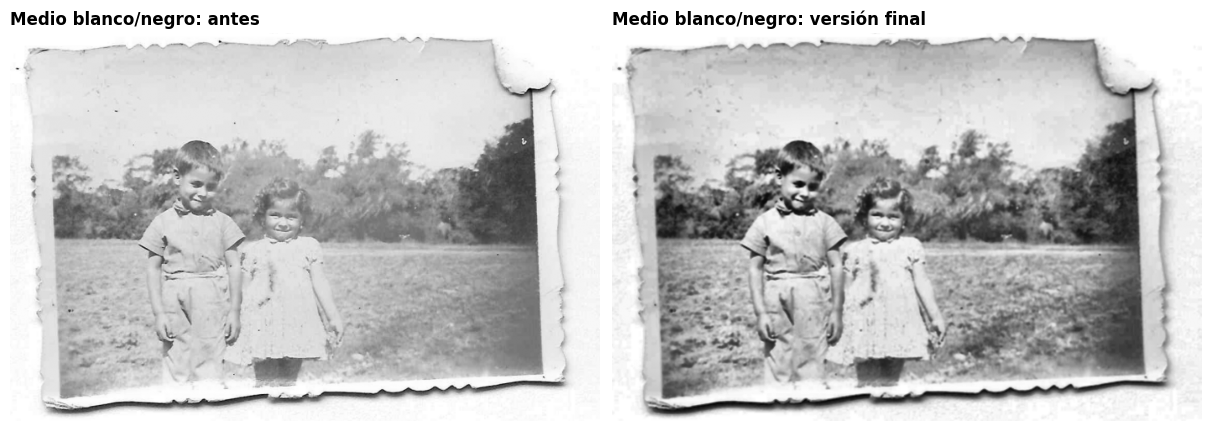

Salida guardada en: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1_Corregido\carpeta_salidas_tfi1\medio_grafico_bn_final.png


In [32]:
# Elegimos la Estrategia 2 (CLAHE) como versión final.
imagen_medio_bn_final = imagen_medio_bn_estrategia_2

justificacion_medio_bn_final = (
    "Se elige la Estrategia 2 (CLAHE) porque responde mejor al problema principal observado: contraste apagado e histograma concentrado en tonos altos. "
    "\nPrimero suaviza el grano leve, después aplica CLAHE para mejorar el contraste local por zonas, y finalmente preserva detalles en áreas claras del papel. "
    "\nFrente a la Estrategia 1 (equalizeHist), produce una imagen más natural sin exagerar el contraste en zonas ya claras. "
    "\nSu límite es que la mejora es más suave que la ecualización global, pero conserva mayor fidelidad a la fotografía original."
)
print(justificacion_medio_bn_final)

if imagen_medio_bn_final is not None:
    ruta_salida_medio_bn = carpeta_salidas_tfi / "medio_grafico_bn_final.png"
    guardar_gris(ruta_salida_medio_bn, imagen_medio_bn_final)

    if imagen_medio_bn_gris is not None:
        mostrar_comparacion(
            imagen_medio_bn_gris,
            imagen_medio_bn_final,
            "Medio blanco/negro: antes",
            "Medio blanco/negro: versión final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_bn.resolve()}")


CONCLUSION: 
"En este caso detectamos que el problema principal era una imagen muy clara y sin contraste, con histograma concentrado en tonos altos (150-255) que hacía que los rostros y el fondo se vieran lavados sin separación clara ni legibilidad.
Probamos dos estrategias comparables. La primera aplicó GaussianBlur(3,3) seguido de equalizeHist para redistribuir todos los tonos en el rango 0-255 de forma global. Mejoró notablemente el contraste entre figuras y fondo, pero puede exagerar el contraste en zonas ya muy claras (cielo, bordes del papel), produciendo una apariencia artificial.
La segunda estrategia aplicó GaussianBlur(3,3) seguido de CLAHE(clipLimit=2.0, tileGridSize=(8,8)), que mejora el contraste de forma local y adaptativa por zonas. Produce una imagen más natural que preserva los detalles en áreas claras del papel sin quemar los bordes.
Por eso elegimos la Estrategia 2. Resolvió mejor el problema de contraste apagado, mejoró la legibilidad de los rostros y el pasto de forma más natural, y mantuvo como límite que la mejora es más suave que la ecualización global, pero conserva mayor fidelidad a la fotografía original."



## Cierre comparativo

Ahora te toca salir del caso puntual y mirar el integrador como conjunto. La pregunta no es solo que funciono, sino tambien **por que convino una estrategia en un caso y no en otro**.





In [33]:
# Construimos una tabla de comparacion final entre los tres casos.
casos = [
    "Camara oscura",
    "Medio grafico color",
    "Medio grafico blanco/negro"
]

problemas_principales = [
    diagnostico_camara_oscura,
    diagnostico_medio_color,
    diagnostico_medio_bn
]

estrategias_finales = [
    justificacion_camara_final,
    justificacion_medio_color_final,
    justificacion_medio_bn_final
]

limites_detectados = [
    "La transformación lineal es uniforme y no adapta la mejora a zonas con diferente iluminación. "
    "El desenfoque óptico propio de la cámara oscura no se puede corregir digitalmente.",

    "La corrección de color es aproximada y no recupera los tonos originales exactos, "
    "porque la imagen ya llega degradada desde la captura o desde el material impreso.",

    "La mejora de contraste con CLAHE es más suave y natural que la ecualización global, "
    "pero sin el dramatismo del histograma global; la imagen conserva más fidelidad "
    "a la fotografía original pero la separación tonal es menos pronunciada.",
]

tabla_final = pd.DataFrame({
    "caso": casos,
    "problema_principal": problemas_principales,
    "decision_final": estrategias_finales,
    "limites": limites_detectados
})

display(tabla_final)


,caso,problema_principal,decision_final,limites
0,Camara oscura,\nLa imagen tiene un fondo negro excesivo (la ...,\nSe elige la Estrategia 1 (convertScaleAbs + ...,La transformación lineal es uniforme y no adap...
1,Medio grafico color,La imagen presenta una dominante rojiza/anaran...,Se elige la estrategia 2 porque responde mejor...,La corrección de color es aproximada y no recu...
2,Medio grafico blanco/negro,Imagen muy clara y sin contraste. Histograma c...,Se elige la Estrategia 2 (CLAHE) porque respon...,La mejora de contraste con CLAHE es más suave ...


## Reflexion final

Respondan con sus palabras:

1. **¿Que decision tecnica les resulto mas dificil de justificar y por que?**

La más difícil fue la elección de parámetros en la corrección de color del caso 2 (medio gráfico color). Bajar la dominante rojiza sin que la imagen quedara artificial implicó ajustar ganancias por canal con np.clip de forma iterativa y sin un criterio único claro: cualquier valor razonable producía un resultado distinto y no había forma objetiva de saber cuándo el color era "correcto", porque la foto original ya llegaba degradada. En los otros dos casos los parámetros tenían una lectura más directa en el histograma.

2. **¿En que caso la mejora fue mas clara y en cual fue mas limitada?**

La mejora fue más clara en el caso 1 (cámara oscura): la transformación lineal con convertScaleAbs produjo un cambio inmediato y visible en el histograma y en la imagen, con una separación tonal mucho más pronunciada entre el follaje y el cielo. La mejora fue más limitada en el caso 2 (medio gráfico color): aunque la dominante bajó, la corrección siguió siendo aproximada y los colores no recuperaron exactamente los tonos originales, porque el daño era cromático y proviene del material impreso o de la captura original.

3. **¿Que aprendieron sobre la relacion entre tipo de degradacion y tipo de operacion?**

Aprendimos que no existe una operación universalmente mejor: la técnica correcta depende del tipo de degradación que presenta la imagen. Cuando la degradación es uniforme (como en la cámara oscura), una corrección global como convertScaleAbs es más directa y efectiva que una adaptativa como CLAHE. Cuando la degradación varía por zonas o por canal (como en el medio color), hay que operar de forma más selectiva sobre el espacio de color adecuado. Usar CLAHE en una imagen con degradación homogénea agrega complejidad sin ventaja real.

4. **¿Que harian distinto si tuvieran una segunda iteracion de trabajo?**

En el caso 1 probaríamos una corrección en dos pasos: primero estimar si hay zonas con diferente nivel de exposición antes de decidir entre corrección global o local. En el caso 2 buscaríamos una imagen de referencia de color neutral para calibrar las ganancias en vez de estimarlas por promedio. En el caso 3 exploraríamos operaciones morfológicas de apertura o clausura después de umbralizar, para limpiar el ruido residual y mejorar aún más la legibilidad del trazo sin perder detalle en los bordes de las figuras.

## Lista de control antes de entregar

- Resolvi los tres casos obligatorios.
- Mostre la imagen original en cada caso.
- Compare al menos dos estrategias por caso.
- Justifique la eleccion final de cada pipeline.
- Guarde las tres imagenes procesadas.
- Complete la tabla final de comparacion.
- Registre el uso de IA de manera breve y critica.
- Escribi una reflexion final con limites del metodo.

## Defensa oral breve

En la defensa cada integrante tiene que poder explicar el problema principal de cada caso, la razon de la estrategia elegida y el limite mas importante de la restauracion realizada.
